<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/NLP/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Subset,DataLoader,random_split
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

# Layer Architecture

In [ ]:
class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(LSTM, self).__init__()
    self.H=hidden_size
    self.fc1=nn.Linear(input_size,4*hidden_size, bias=True)
    self.fc2=nn.Linear(hidden_size,4*hidden_size, bias=False)

  def forward(self,x,h_prev,c_prev):
    A=self.fc1(x)+self.fc2(h_prev)

    f=torch.sigmoid(A[:,:self.H])
    i=torch.sigmoid(A[:,self.H:2*self.H])
    o=torch.sigmoid(A[:,2*self.H:3*self.H])
    g=torch.tanh(A[:,3*self.H:])

    c=f*c_prev+i*g
    h=o*torch.tanh(c)

    return h,c

In [ ]:
class TimeLSTM(nn.Module):
  def __init__(self, input_size,hidden_size, dropout=0.0):
    super(TimeLSTM, self).__init__()
    self.cell=LSTM(input_size, hidden_size)
    self.dropout_layer = nn.Dropout(p=dropout)
    self.hidden_size=hidden_size

    self.h, self.c= None, None

  def forward(self,xs,h0=None,c0=None):
    batch_size,seq_size,_=xs.shape

    if h0 is not None:
        self.h = h0
        self.c = c0
    elif self.h is None:
        self.h = xs.new_zeros(batch_size, self.hidden_size)
        self.c = xs.new_zeros(batch_size, self.hidden_size)

    ones = xs.new_ones(batch_size, self.hidden_size)
    mask = self.dropout_layer(ones)

    hs=xs.new_zeros(batch_size, seq_size, self.hidden_size)
    for t in range(seq_size):
      h_input = self.h * mask
      self.h, self.c = self.cell(xs[:,t,:],h_input,self.c)
      hs[:,t,:]=self.h
      # c 에서는 mask 쓰면 안 됨

    return hs

  def detach_state(self):
    if self.h is not None:
        self.h = self.h.detach()
        self.c = self.c.detach()

  def reset_state(self):
    self.h, self.c = None, None

In [ ]:
class TimeDropout(nn.Module):
  def __init__(self, dropout=0.0):
    super(TimeDropout, self).__init__()
    self.dropout_layer=nn.Dropout(p=dropout)

  def forward(self,xs):
    batch_size, _, hidden_size = xs.shape
    ones=xs.new_ones(batch_size,1,hidden_size)
    mask=self.dropout_layer(ones)
    return xs*mask

In [ ]:
class TimeEmbedding(nn.Module):
  def __init__(self,vocab_size,embedding_dim):
    super(TimeEmbedding, self).__init__()
    self.embedding=nn.Embedding(vocab_size,embedding_dim)

  def forward(self,idxs):
    return self.embedding(idxs)

In [ ]:
class TimeLinear(nn.Module):
  def __init__(self,input_size,output_size):
    super(TimeLinear, self).__init__()
    self.linear=nn.Linear(input_size,output_size)

  def forward(self,xs):
    return self.linear(xs)

In [ ]:
class TimeCrossEntropy(nn.Module):
  def __init__(self):
    super(TimeCrossEntropy, self).__init__()
    self.CrossEntropy=nn.CrossEntropyLoss(reduction='mean')

  def forward(self, xs, ts):
    batch_size, seq_size, _ = xs.shape
    xs = xs.reshape(batch_size * seq_size, -1)
    ts = ts.reshape(-1)
    return self.CrossEntropy(xs, ts)

In [ ]:
class LSTMlm(nn.Module):
  def __init__(self,vocab_size,embedding_dim,hidden_size,num_layers=2,dropout=0.0):
    super(LSTMlm, self).__init__()
    self.embedding=TimeEmbedding(vocab_size,embedding_dim)
    self.time_dropout=TimeDropout(dropout)
    self.lstm=TimeLSTM(embedding_dim,hidden_size,dropout=0.0)

    layers=[TimeDropout(dropout)]
    for _ in range(num_layers-1):
      layers.append(TimeLSTM(hidden_size,hidden_size,dropout=0.0))
      layers.append(TimeDropout(dropout))

    self.lstm_layers=nn.Sequential(*layers)

    self.linear=TimeLinear(hidden_size,vocab_size)
    self.loss=TimeCrossEntropy()

    if embedding_dim==hidden_size:
        self.linear.linear.weight=self.embedding.embedding.weight

  def forward(self,xs,ts,h0=None,c0=None):
    xs=self.embedding(xs)
    xs=self.time_dropout(xs)
    xs=self.lstm(xs,h0,c0)
    xs=self.lstm_layers(xs)
    xs=self.linear(xs)
    return self.loss(xs,ts)

  def reset_state(self):
    for m in self.modules():
      if isinstance(m, TimeLSTM):
          m.reset_state()

  def detach_state(self):
    for m in self.modules():
      if isinstance(m, TimeLSTM):
          m.detach_state()

  def predict(self,xs):
    xs=self.embedding(xs)
    xs=self.time_dropout(xs)
    xs=self.lstm(xs)
    xs=self.lstm_layers(xs)
    xs=self.linear(xs)
    return xs

# Dataset

In [ ]:
import urllib.request

base_url = "https://raw.githubusercontent.com/wojzaremba/lstm/master/data/"
files = ["ptb.train.txt", "ptb.valid.txt", "ptb.test.txt"]

for f in files:
    urllib.request.urlretrieve(base_url + f, f)

In [ ]:
def load_ptb(filepath):
    with open(filepath, 'r') as f:
        words = f.read().replace('\n', ' <eos> ').split()
    return words

In [ ]:
def to_tensor(words, word2idx):
    return torch.tensor([word2idx[w] for w in words], dtype=torch.long)

In [ ]:
def batchify(data, batch_size):
    n_batch = data.size(0) // batch_size
    data = data[:n_batch * batch_size]  # 나머지 자르기
    data = data.view(batch_size, -1).contiguous()
    return data

In [ ]:
train_words = load_ptb('ptb.train.txt')
valid_words = load_ptb('ptb.valid.txt')
test_words = load_ptb('ptb.test.txt')

vocab = sorted(set(train_words))
word2idx = {w: i for i, w in enumerate(vocab)}

train_data = to_tensor(train_words, word2idx)
valid_data = to_tensor(valid_words, word2idx)
test_data = to_tensor(test_words, word2idx)

In [ ]:
train_xs=train_data[:-1]
train_ts=train_data[1:]

valid_xs=valid_data[:-1]
valid_ts=valid_data[1:]

test_xs=test_data[:-1]
test_ts=test_data[1:]

In [ ]:
def evaluate_perplexity(model, xs_b, ts_b, seq_size, device):
    model.eval()
    model.reset_state()

    total_loss = 0.0   # token 단위 loss 합
    total_tokens = 0    # 실제 처리한 token 개수

    with torch.no_grad():
        for x_chunk, t_chunk in get_batches(xs_b, ts_b, seq_size):
            x_chunk = x_chunk.to(device)
            t_chunk = t_chunk.to(device)

            batch_size, chunk_len = x_chunk.shape
            n_tokens = batch_size * chunk_len  # 이 chunk가 포함하는 토큰 수

            loss = model(x_chunk, t_chunk)  # chunk 내 평균 loss (reduction='mean')
            total_loss += loss.item() * n_tokens  # 평균을 다시 합으로 복원
            total_tokens += n_tokens

    model.reset_state()

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return perplexity, avg_loss

# Train

In [ ]:
# %%script echo skip

epochs=50
start_epoch=0
learning_rate=1.0
batch_size=20
early_stop_patience = 5
device='cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# %%script echo skip

vocab_size=len(vocab)
embedding_dim=650
hidden_size=650
dropout=0.5
seq_size=35

In [ ]:
# %%script echo skip

train_xs_b = batchify(train_xs, batch_size)
train_ts_b = batchify(train_ts, batch_size)

valid_xs_b = batchify(valid_xs, batch_size)
valid_ts_b = batchify(valid_ts, batch_size)

test_xs_b = batchify(test_xs, batch_size)
test_ts_b = batchify(test_ts, batch_size)

In [ ]:
best_loss=float('inf')
no_improve=0
train_loss_list=[]
val_loss_list=[]
test_ppl_list=[]

In [ ]:
def init_weights(model, init_range=0.05):
    for name, param in model.named_parameters():
        nn.init.uniform_(param, -init_range, init_range)

In [ ]:
def get_batches(xs_b, ts_b, seq_size):
    total_len = xs_b.size(1)
    for i in range(0, total_len - 1, seq_size):
        end = min(i + seq_size, total_len)
        x_chunk = xs_b[:, i:end]   # (batch_size, chunk_len)
        t_chunk = ts_b[:, i:end]   # (batch_size, chunk_len)
        yield x_chunk, t_chunk

In [ ]:
# %%script echo skip

model=LSTMlm(
    vocab_size,
    embedding_dim,
    hidden_size,
    dropout=dropout
).to(device)

init_weights(model)
optimizer=optim.SGD(model.parameters(),lr=learning_rate)
scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=1,gamma=0.8)

In [ ]:
# path = f'/content/drive/MyDrive/LSTMlm.pth'

# path = f'/content/drive/MyDrive/LSTMlm2.pth'

# path = f'/content/drive/MyDrive/LSTMlm3.pth'

path = f'/content/drive/MyDrive/LSTMlm4pth'

In [ ]:
lr_decay_start_epoch = 6

train_total = math.ceil((train_xs_b.size(1) - 1) / seq_size)
val_total=math.ceil((valid_xs_b.size(1) - 1) / seq_size)
test_total = math.ceil((test_xs_b.size(1) - 1) / seq_size)

In [ ]:
%%script echo skip
if os.path.exists(path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    train_loss_list = checkpoint['train_loss_list']
    val_loss_list = checkpoint['val_loss_list']
    test_ppl_list = checkpoint['test_ppl_list']
    best_loss = checkpoint['best_loss']
    start_epoch = checkpoint['epoch']+1

In [ ]:
# %%script echo skip

for epoch in tqdm(range(start_epoch, epochs), desc="Epoch"):

  train_loss=0.0
  val_loss=0.0
  model.train()

  for x_chunk, t_chunk in tqdm(get_batches(train_xs_b, train_ts_b, seq_size), desc="Iteration", leave=False, total=train_total):
    x_chunk=x_chunk.to(device)
    t_chunk=t_chunk.to(device)



    model.detach_state()
    optimizer.zero_grad()
    loss=model(x_chunk,t_chunk)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
    optimizer.step()
    train_loss+=loss.item()

  model.eval()
  model.reset_state()
  with torch.no_grad():
    for x_chunk, t_chunk in tqdm(get_batches(valid_xs_b, valid_ts_b, seq_size), desc="Validation", leave=False,total=val_total):
      x_chunk=x_chunk.to(device)
      t_chunk=t_chunk.to(device)
      loss=model(x_chunk,t_chunk)
      val_loss+=loss.item()

  model.reset_state()
  train_loss/=train_total
  val_loss/=val_total
  train_loss_list.append(train_loss)
  val_loss_list.append(val_loss)

  if epoch >= lr_decay_start_epoch:
      scheduler.step()

  test_ppl, test_loss = evaluate_perplexity(model, test_xs_b, test_ts_b, seq_size, device)
  test_ppl_list.append(test_ppl)

  if val_loss < best_loss:
        best_loss = val_loss
        no_improve = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_loss': best_loss,
            'train_loss_list': train_loss_list,
            'val_loss_list': val_loss_list,
            'test_ppl_list': test_ppl_list,
            'epoch': epoch
        }, path)
  else:
      no_improve += 1
      if no_improve >= early_stop_patience:
          print(f"Early Stopping at Epoch {epoch+1}")
          break

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_loss_list, label='train')
axes[0].plot(val_loss_list, label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(test_ppl_list, label='test')
axes[1].set_title('Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')

plt.show()

스케줄러를 너무 빠르게 시작함

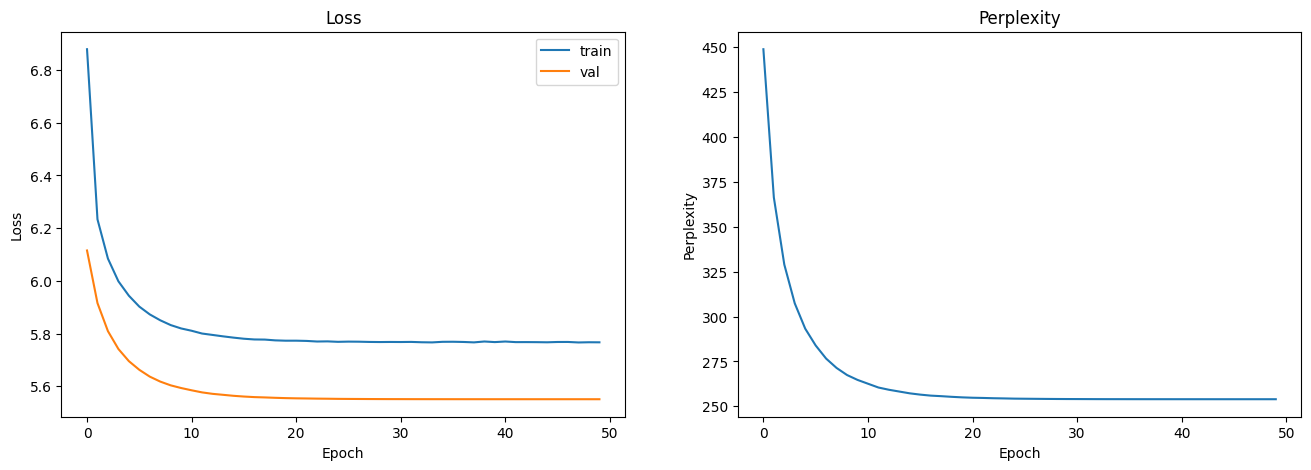

-> 5 에포크 이후로 부터 하게끔 조정

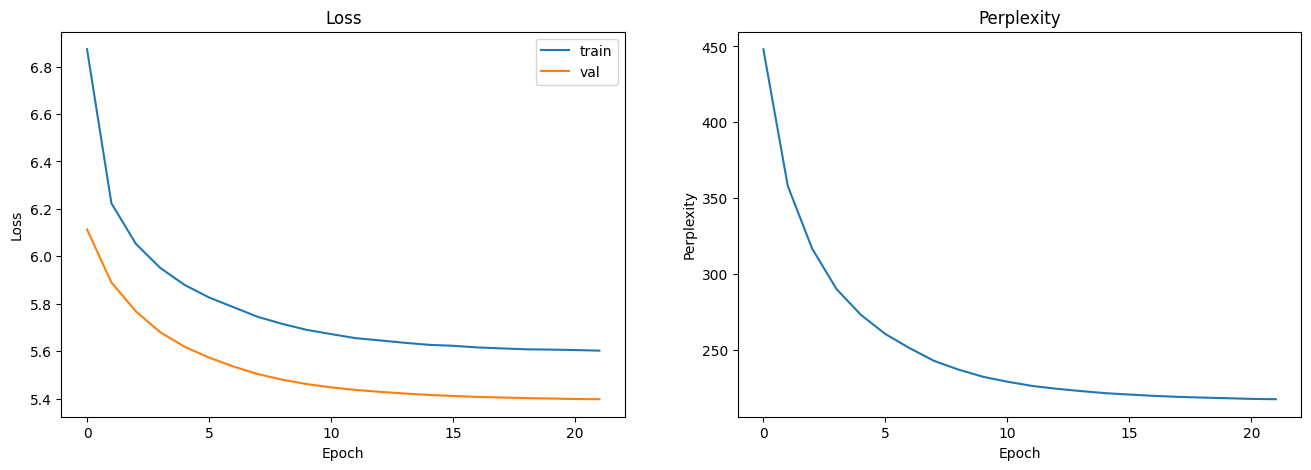

-> Embedding weight 초기화

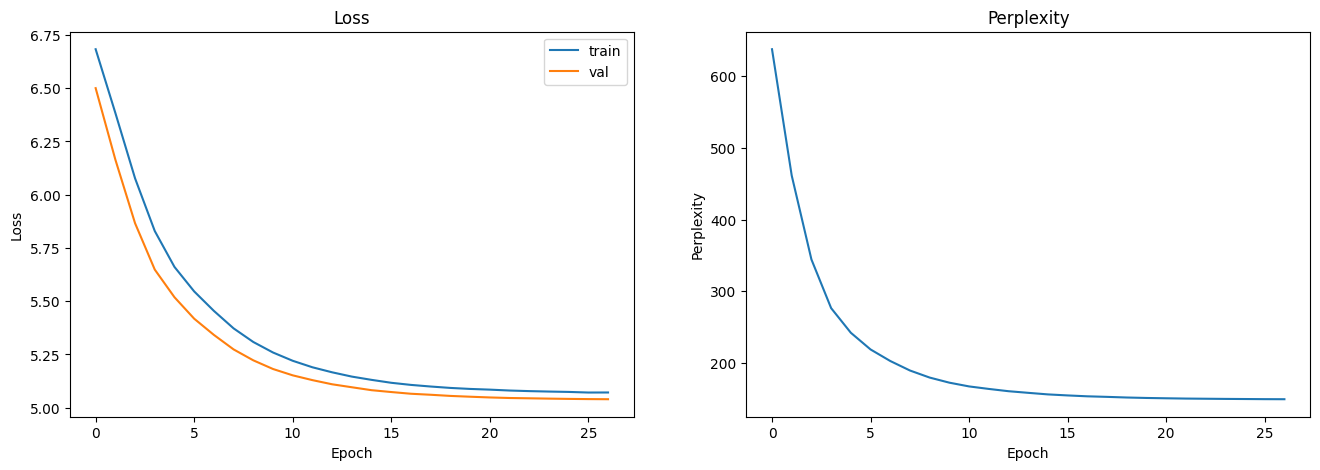